# Analysis walkthrough

CPU-only walkthrough of the analysis pipeline using committed result JSONs.
No GPU, no model downloads, no HuggingFace. Runs in under 30 seconds.

Install: `uv sync` or `pip install -e .`


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from analysis import load_all_models, load_model_means, family_f_stat, load_control_sensitivity
from analysis.permutation_test import run_permutation_test, n_unique_permutations


## 1. The cross-family scope

Load all 22 paper-scope models (13 cross-family + 9 Pythia controlled suite).


In [ ]:
models = load_all_models()
print(f"{len(models)} models across {len(set(m['family'] for m in models.values()))} families")
print()
print(f"{'Model':<18} {'Family':<10} {'Params':>7} {'pcorr':>8} {'Seeds':>6}")
print('-' * 55)
for label, m in sorted(models.items(), key=lambda x: -x[1]['partial_corr']['mean']):
    pc = m['partial_corr']
    n = len(pc.get('per_seed', []))
    print(f"{label:<18} {m['family']:<10} {m['params_b']:>6.2f}B {pc['mean']:>+.3f}  {n:>5}")


22 models across 7 families

Model              Family      Params    pcorr  Seeds
-------------------------------------------------------
Gemma-1B           Gemma        1.00B +0.388      7
Pythia-160M        Pythia       0.16B +0.382      7
Mistral-7B         Mistral      7.25B +0.313      7
Pythia-70M         Pythia       0.07B +0.301      7
Phi-3-Mini         Phi          3.82B +0.300      7
GPT2-1.5B          GPT-2        1.56B +0.290      3
GPT2-124M          GPT-2        0.12B +0.290      3
GPT2-774M          GPT-2        0.77B +0.286      3
GPT2-355M          GPT-2        0.35B +0.279      3
Qwen-1.5B          Qwen         1.50B +0.275      7
Qwen-3B            Qwen         3.00B +0.263      7
Qwen-7B            Qwen         7.60B +0.255      7
Pythia-1B          Pythia       1.00B +0.246      7
Pythia-6.9B        Pythia       6.90B +0.240      7
Pythia-12B         Pythia      12.00B +0.238      7
Qwen-0.5B          Qwen         0.50B +0.215      7
Qwen-14B           Qwen      

## 2. What partial correlation measures

Raw probe-loss correlation runs from +0.50 to +0.60, but most of that is redundant with confidence. Partial correlation controls for max softmax and activation norm, isolating the signal that output confidence cannot explain.

The control sensitivity data shows this decomposition for each model.


In [ ]:
cs = load_control_sensitivity()
print(f"{'Model':<18} {'Raw':>7} {'Controlled':>11} {'Gap':>7}")
print('-' * 48)
for m in cs:
    raw = m['none']
    ctrl = m['standard']
    gap = (1 - ctrl / raw) * 100 if raw > 0 else 0
    print(f"{m['name']:<18} {raw:+.3f}   {ctrl:+.3f}     {gap:4.0f}%")


Model                  Raw  Controlled     Gap
------------------------------------------------
GPT2-124M          +0.549   +0.282       49%
Qwen-0.5B          +0.534   +0.206       61%
Qwen-1.5B          +0.620   +0.235       62%
Qwen-3B            +0.662   +0.288       56%
Qwen-7B            +0.650   +0.240       63%
Qwen-14B           +0.697   +0.253       64%
Llama-3B           +0.247   +0.089       64%
Gemma-1B           +0.491   +0.387       21%
Mistral-7B         +0.739   +0.314       58%
Phi-3-Mini         +0.703   +0.300       57%
Pythia-70M         +0.340   +0.300       12%
Pythia-160M        +0.549   +0.388       29%
Pythia-410M        +0.175   +0.107       39%
Pythia-1B          +0.555   +0.235       58%
Pythia-1.4B        +0.297   +0.105       65%
Pythia-1.4B-deduped +0.317   +0.096       70%
Pythia-2.8B        +0.538   +0.205       62%
Pythia-6.9B        +0.604   +0.233       61%
Pythia-12B         +0.601   +0.235       61%


## 3. The family effect

Does architecture family predict observability after controlling for scale? The permutation test shuffles family labels and computes F-statistics to build a null distribution.


In [ ]:
means = load_model_means()
families = [m[0] for m in means]
log_params = np.array([m[1] for m in means])
pcorrs = np.array([m[2] for m in means])

observed_f = family_f_stat(families, log_params, pcorrs)
n_unique = n_unique_permutations(families)
print(f"Observed F = {observed_f:.2f}")
print(f"{n_unique:,} unique permutations (Monte Carlo, 50k samples)")

# Monte Carlo null distribution (exact enumeration infeasible at this scope)
rng = np.random.RandomState(42)
mc_n = 50000
null_fs = np.array([
    family_f_stat(list(rng.permutation(families)), log_params, pcorrs)
    for _ in range(mc_n)
])

p_value = float((null_fs >= observed_f).mean())
min_p = 1.0 / mc_n
print(f"p = {p_value:.4f} (minimum achievable: {min_p:.6f})")

Observed F = 2.30
1,075,501,627,200 unique permutations (Monte Carlo, 50k samples)
p = 0.0804 (minimum achievable: 0.000020)


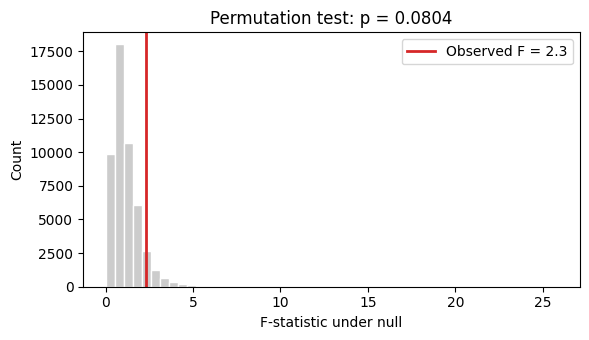

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(null_fs, bins=50, color='#cccccc', edgecolor='white')
ax.axvline(observed_f, color='#d62728', lw=2, label=f'Observed F = {observed_f:.1f}')
ax.set_xlabel('F-statistic under null')
ax.set_ylabel('Count')
ax.set_title(f'Permutation test: p = {p_value:.4f}')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Output-controlled residual

The OC residual measures how much signal remains after controlling for a trained MLP on the full output representation. Models at the collapse point sit near the origin.


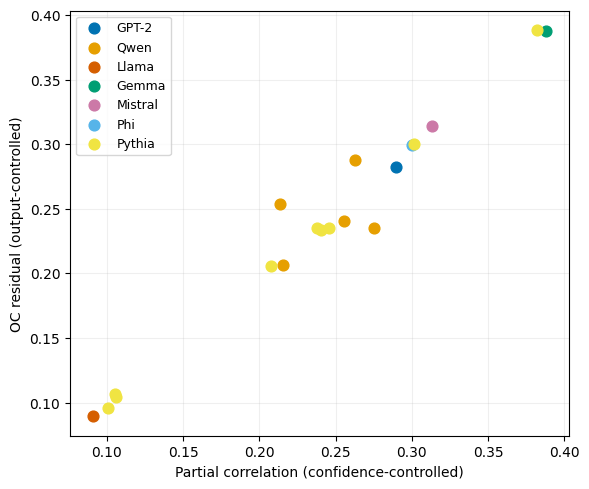

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {
    'GPT-2': '#0072B2', 'Qwen': '#E69F00', 'Llama': '#D55E00',
    'Gemma': '#009E73', 'Mistral': '#CC79A7', 'Phi': '#56B4E9', 'Pythia': '#F0E442',
}
plotted = set()
for label, m in models.items():
    pc = m['partial_corr']['mean']
    oc = m.get('control_sensitivity', {}).get('standard')
    if oc is None:
        continue
    fam = m['family']
    ax.scatter(pc, oc, c=colors.get(fam, 'gray'), s=60, zorder=3,
               label=fam if fam not in plotted else None)
    plotted.add(fam)
ax.set_xlabel('Partial correlation (confidence-controlled)')
ax.set_ylabel('OC residual (output-controlled)')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 5. Pythia collapse pattern

Within the Pythia suite (same lab, same training recipe, same data), three configurations at (24 layers, 16 heads) collapse to pcorr ~0.10. Six other depths produce healthy signal.


In [ ]:
pythia = {l: m for l, m in models.items() if m['family'] == 'Pythia'}
print(f"{'Model':<22} {'Params':>7} {'pcorr':>8}  Status")
print('-' * 55)
for label, m in sorted(pythia.items(), key=lambda x: x[1]['params_b']):
    pc = m['partial_corr']['mean']
    status = 'COLLAPSED' if pc < 0.15 else 'healthy'
    print(f"{label:<22} {m['params_b']:>6.2f}B {pc:>+.3f}   {status}")


Model                   Params    pcorr  Status
-------------------------------------------------------
Pythia-70M               0.07B +0.301   healthy
Pythia-160M              0.16B +0.382   healthy
Pythia-410M              0.41B +0.105   COLLAPSED
Pythia-1B                1.00B +0.246   healthy
Pythia-1.4B              1.40B +0.106   COLLAPSED
Pythia-1.4B-deduped      1.40B +0.100   COLLAPSED
Pythia-2.8B              2.80B +0.208   healthy
Pythia-6.9B              6.90B +0.240   healthy
Pythia-12B              12.00B +0.238   healthy
